Setting up the environment from part-1

In [2]:
#Question -2- Defined the RL environment
import random

class AlienPlanetEnv:
    def __init__(self):
        self.grid = [
            ["S", ".", "C", "X", ".", "."],
            [".", "X", ".", "A", ".", "."],
            [".", ".", ".", ".", "X", "."],
            [".", ".", "X", "X", "X", "."],
            [".", "A", ".", ".", ".", "."],
            [".", ".", ".", "G", ".", "C"]
        ]
        self.original_grid = [row[:] for row in self.grid]
        self.row_count = len(self.grid)
        self.column_count = len(self.grid[0])
        self.start_pos = (0, 0)
        self.agent_pos = self.start_pos
        self.actions = {0: (-1,0), 1: (1,0), 2: (0,-1), 3: (0,1)}
        self.rewards = {
            ".": -1,
            "X": -5,
            "A": -10,
            "C": 4,
            "G": 20,
            "Wall": -5
        }
        self.done = False

    def position_to_index(self, pos):
        row, column = pos
        return row * self.column_count + column


    def index_to_position(self, idx):
        return (idx // self.column_count, idx % self.column_count)

    def reset(self):
        self.grid = [row[:] for row in self.original_grid]
        self.agent_pos = self.start_pos
        self.done = False
        return self.position_to_index(self.agent_pos)

    def step(self, action):
        if self.done:
            return self.position_to_index(self.agent_pos), 0, self.done

        row, col = self.agent_pos
        row_direction, col_direction = self.actions.get(action, (0,0))
        updated_row, updated_col = row + row_direction, col + col_direction

        if updated_row < 0 or updated_row >= self.row_count or updated_col < 0 or updated_col >= self.column_count:
            reward = self.rewards["Wall"]
            return self.position_to_index(self.agent_pos), reward, self.done

        cell = self.grid[updated_row][updated_col]
        reward = self.rewards.get(cell, -1)
        self.agent_pos = (updated_row, updated_col)

        if cell == "C":
            self.grid[updated_row][updated_col] = "."

        if cell == "G":
            self.done = True

        return self.position_to_index(self.agent_pos), reward, self.done

    def render(self):
        for r in range(self.row_count):
            row_cells = ""
            for c in range(self.column_count):
                if (r,c) == self.agent_pos:
                    row_cells += "A "
                else:
                    row_cells += f"{self.grid[r][c]} "
            print(row_cells)
        print("\n")

In [3]:
#Question-1 SARSA Algorithm along with training loop is initilaised
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def train_sarsa(env, episodes=500, max_steps=100, alpha=0.1, gamma=0.95, epsilon_start=1.0, epsilon_min=0.05, epsilon_decay=0.995, seed=None):

    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    state_count = env.row_count * env.column_count
    action_list = len(env.actions)
    Q = np.zeros((state_count, action_list), dtype=float)

    eps = epsilon_start
    episode_rewards = []
    epsilons = []

    for ep in range(episodes):
        state = env.reset()

        if random.random() < eps:
            action=random.choice(range(action_list))
        else:
            action=int(np.argmax(Q[state]))

        total_reward = 0.0

        for t in range(max_steps):
            next_state, reward, done = env.step(action)
            total_reward = total_reward + reward

            if random.random() < eps:
                next_action = random.choice(range(action_list))
            else:
                next_action = int(np.argmax(Q[next_state]))
            td_target = reward + gamma * Q[next_state, next_action]
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error

            state, action = next_state, next_action
            if done:
                break

        epsilons.append(eps)
        episode_rewards.append(total_reward)
        eps = max(epsilon_min, eps * epsilon_decay)

    return Q, episode_rewards, epsilons


In [4]:
#Qtable formatting function
def Qtable_format(Q, env):
    labels = []
    for index in range(env.row_count * env.column_count):
        pos = env.index_to_position(index)
        labels.append(f"{pos}")
    df = pd.DataFrame(Q, index=labels, columns=["Up(0)", "Down(1)", "Left(2)", "Right(3)"])
    return df

Initial Q-table (zeros):
        Up(0)  Down(1)  Left(2)  Right(3)
(0, 0)    0.0      0.0      0.0       0.0
(0, 1)    0.0      0.0      0.0       0.0
(0, 2)    0.0      0.0      0.0       0.0
(0, 3)    0.0      0.0      0.0       0.0
(0, 4)    0.0      0.0      0.0       0.0
(0, 5)    0.0      0.0      0.0       0.0
(1, 0)    0.0      0.0      0.0       0.0
(1, 1)    0.0      0.0      0.0       0.0
(1, 2)    0.0      0.0      0.0       0.0
(1, 3)    0.0      0.0      0.0       0.0
(1, 4)    0.0      0.0      0.0       0.0
(1, 5)    0.0      0.0      0.0       0.0
(2, 0)    0.0      0.0      0.0       0.0
(2, 1)    0.0      0.0      0.0       0.0
(2, 2)    0.0      0.0      0.0       0.0
(2, 3)    0.0      0.0      0.0       0.0
(2, 4)    0.0      0.0      0.0       0.0
(2, 5)    0.0      0.0      0.0       0.0
(3, 0)    0.0      0.0      0.0       0.0
(3, 1)    0.0      0.0      0.0       0.0
(3, 2)    0.0      0.0      0.0       0.0
(3, 3)    0.0      0.0      0.0       0.0
(3, 4)   

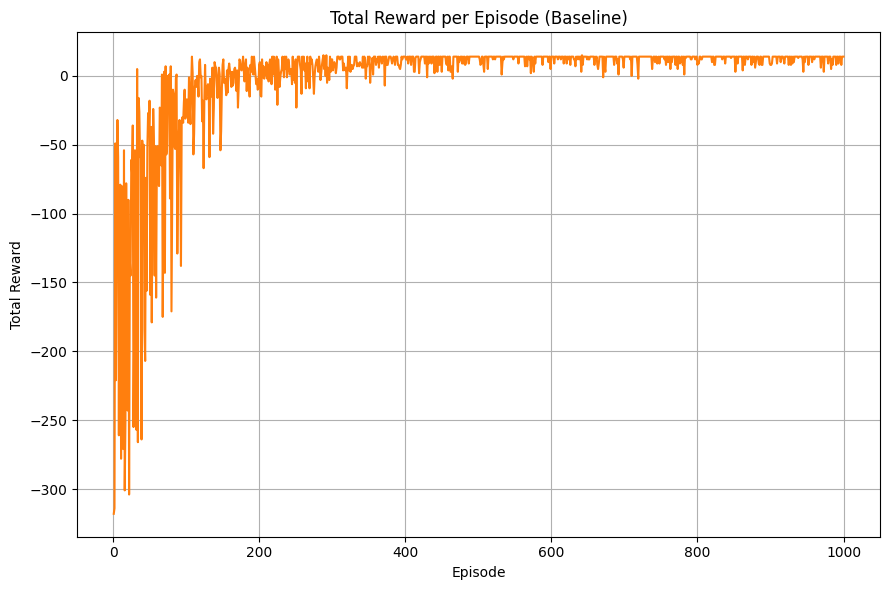

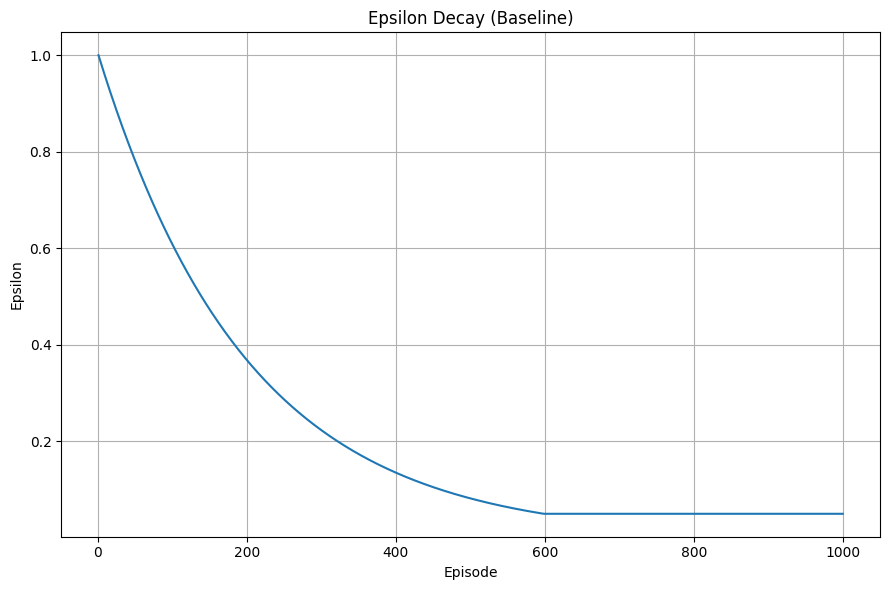


Greedy evaluation rewards for 10 episodes:
[14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0]


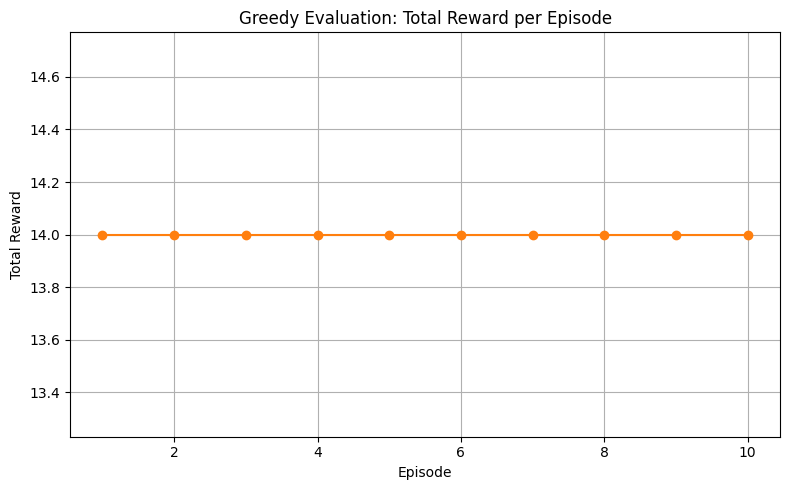

In [5]:
#Question-2
#Printed the initial and trained Q table
#Reward per episode plotted
#Eps decay graph plotted
#Evaluation performed for 10 epochs
SEED = 50
env = AlienPlanetEnv()


state_count = env.row_count * env.column_count
initial_Q = np.zeros((state_count, 4))
print("Initial Q-table (zeros):")
print(Qtable_format(initial_Q, env).to_string())


episodes = 1000
max_steps = 100
alpha = 0.1
gamma = 0.99
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995


Q_trained, rewards, epsilons = train_sarsa(env, episodes=episodes, max_steps=max_steps, alpha=alpha, gamma=gamma, epsilon_start=epsilon_start, epsilon_min=epsilon_min, epsilon_decay=epsilon_decay, seed=SEED)

print("\nTrained Q-table (baseline):")
print(Qtable_format(Q_trained, env).to_string())


plt.figure(figsize=(9,6))
plt.plot(range(1, len(rewards) + 1), rewards, color="tab:orange")
plt.title("Total Reward per Episode (Baseline)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9,6))
plt.plot(range(1, len(epsilons) + 1), epsilons, color="tab:blue")
plt.title("Epsilon Decay (Baseline)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(True)
plt.tight_layout()
plt.show()


def evaluate_greedy(env, Q, episodes=10, max_steps=100):
    rewards_eval = []
    for ep in range(episodes):
        state = env.reset()
        total = 0.0
        for t in range(max_steps):
            action = int(np.argmax(Q[state]))
            state, reward, done = env.step(action)
            total += reward
            if done:
                break
        rewards_eval.append(total)
    return rewards_eval

greedy_rewards = evaluate_greedy(env, Q_trained, episodes=10, max_steps=100)
print("\nGreedy evaluation rewards for 10 episodes:")
print(greedy_rewards)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(greedy_rewards)+1), greedy_rewards, marker='o', color="tab:orange")
plt.title("Greedy Evaluation: Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.tight_layout()
plt.show()




In [9]:
#Question-3
#We are considering 2 hyperparameters (gamma and epsilon values)with 3 different values.
#We are looping over each epsilon and gamma values and storing the results in the output array.
#We are condidering the average of last 150 Rewards as when we observed in the last graph we saw that the agent will stablise and learn in the later episodes.
#Later we are extracting the best values and evaluating the model.
#We found that the best hyper parameter values are 0.95 and 0.995 respectively.

gammas = [0.90, 0.95, 0.99]
eps_decays = [0.990, 0.995, 0.999]

outputs = []

for gamma_values in gammas:
    for decay_values in eps_decays:
        Qlist, rewards_list, eps_list = train_sarsa(env,episodes=1000,max_steps=100,alpha=0.1,gamma=gamma_values,epsilon_start=1.0,epsilon_min=0.05,epsilon_decay=decay_values,seed=SEED)
        outputs.append({"gamma": gamma_values,"eps_decay": decay_values,"avg_last150": np.mean(rewards_list[-150:]), "Q": Qlist,"rewards": rewards_list,"eps": eps_list })

df = pd.DataFrame([{"gamma": r["gamma"],"eps_decay": r["eps_decay"],"avg_last150": r["avg_last150"]} for r in outputs])

print("\nTuning Results:")
print(df.to_string(index=False))

best_reward = max(outputs, key=lambda x: x["avg_last150"])
best_gamma = best_reward["gamma"]
best_decay = best_reward["eps_decay"]
best_Q = best_reward["Q"]
best_rewards_list = best_reward["rewards"]
best_eps_list = best_reward["eps"]

print("\nBest Hyperparameters Found:")
print(best_reward["gamma"], best_reward["eps_decay"])
print("Reward (last 150 episodes):", best_reward["avg_last150"])

print("\nBest Q-table:")
print(Qtable_format(best_Q, env).to_string())



Tuning Results:
 gamma  eps_decay  avg_last150
  0.90      0.990    11.593333
  0.90      0.995    12.653333
  0.90      0.999    -1.646667
  0.95      0.990    11.953333
  0.95      0.995    13.006667
  0.95      0.999    -1.733333
  0.99      0.990    12.993333
  0.99      0.995    12.493333
  0.99      0.999    -1.500000

Best Hyperparameters Found:
0.95 0.995
Reward (last 150 episodes): 13.006666666666666

Best Q-table:
            Up(0)    Down(1)    Left(2)   Right(3)
(0, 0)  -3.987537  -9.959345  -3.313651   8.186865
(0, 1)  -2.750657  -8.366162  -1.385058   9.699728
(0, 2)  -6.653365   6.342751   1.031588 -12.843488
(0, 3) -10.288798 -13.371611  -8.511805  -7.939264
(0, 4)  -8.892501  -8.049716 -10.167150  -6.115704
(0, 5) -10.398059  -3.275872  -7.263604  -9.764007
(1, 0) -10.550601  -7.351043 -13.935612 -11.331047
(1, 1)  -8.932472   2.355000  -9.464236  -8.483984
(1, 2)  -3.731062   8.185869  -9.586720  -7.746590
(1, 3)  -9.888092   8.160912  -8.495376  -7.449008
(1, 4)  -7

**Question-4**

How Hyperparameters Influence Performance Factors:

**Gamma (γ) - Discount Factor**


This hyperparameter controls how much the agent values future rewards.
If we consider the gamma values in 2 different categories we infer this:

**Low γ (0.90)**: The agent acts shortsighted i.e it  only considers immediate rewards, this provided poor performance in the current grid.

**High γ (0.95, 0.99):** The agent plans ahead to consider long-term reward.

In this case,  γ=0.95 performs best because the task requires planning the full path to the goal.

**Epsilon Decay (ε_decay)**

This hyperparameter controls how fast the agent transitions from exploration (performing random actions) to exploitation.

The value represents the percentage of exploration retained after each episode.
In the above case:

**Fast decay (0.990):** Quickly stops exploring.

**Medium decay (0.995):** Balanced exploration.

**Slow decay (0.999)**: Explores too long, never fully commits to optimal policy → Failed with negative rewards

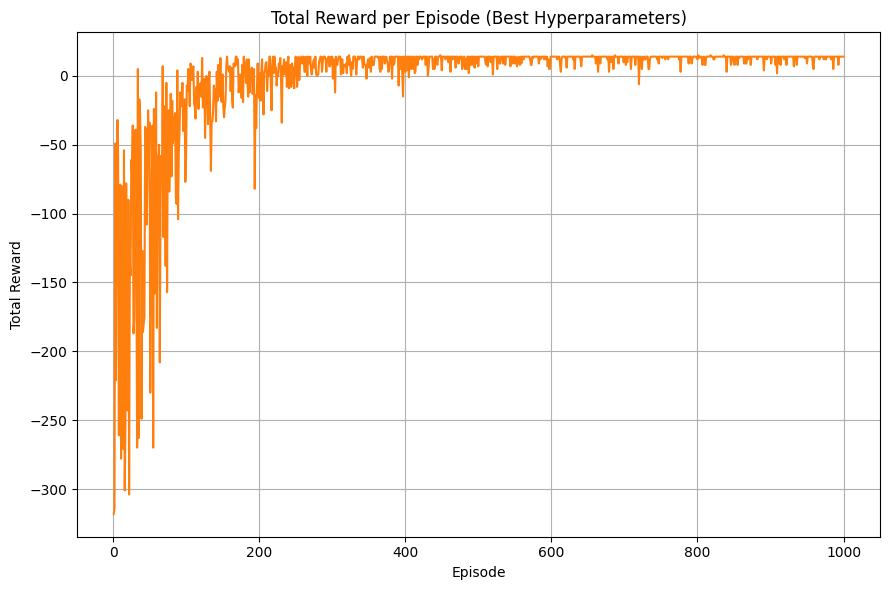

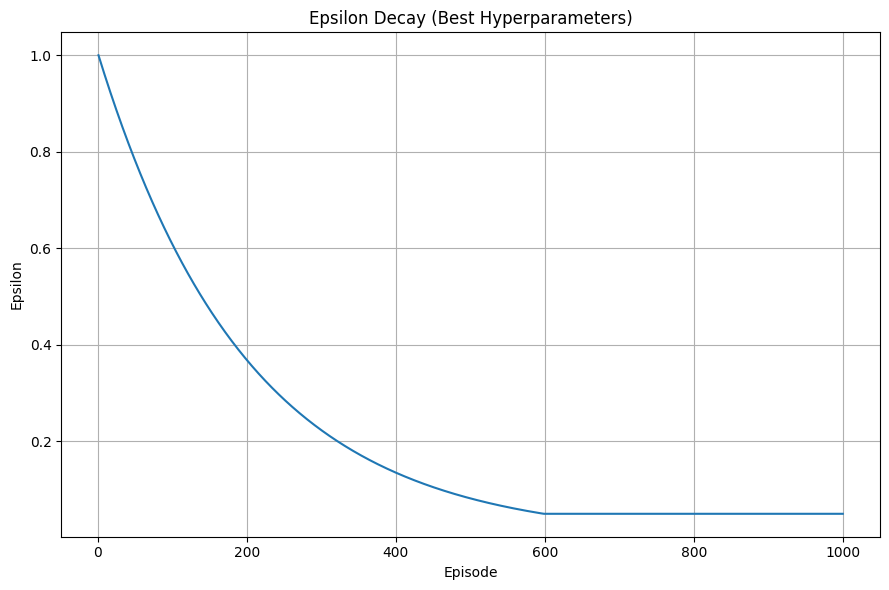


Greedy Evaluation Rewards (Best Hyperparameters):
[14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0]


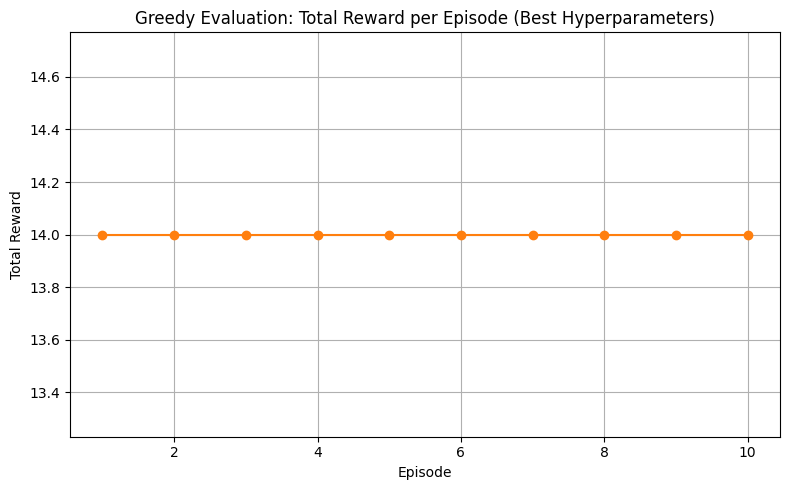

In [10]:
#Question -5 Plots using the best hyperparameters obtained and the best Q table.
plt.figure(figsize=(9,6))
plt.plot(range(1, len(best_rewards_list)+1), best_rewards_list, color="tab:orange")
plt.title("Total Reward per Episode (Best Hyperparameters)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.tight_layout()
plt.show()



plt.figure(figsize=(9,6))
plt.plot(range(1, len(best_eps_list)+1), best_eps_list, color="tab:blue")
plt.title("Epsilon Decay (Best Hyperparameters)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(True)
plt.tight_layout()
plt.show()



def evaluate_greedy(env, Q, episodes=10, max_steps=100):
    rewards_eval = []
    for ep in range(episodes):
        state = env.reset()
        total = 0.0
        for t in range(max_steps):
            action = int(np.argmax(Q[state]))
            state, reward, done = env.step(action)
            total += reward
            if done:
                break
        rewards_eval.append(total)
    return rewards_eval


greedy_rewards = evaluate_greedy(env, best_Q, episodes=10, max_steps=100)
print("\nGreedy Evaluation Rewards (Best Hyperparameters):")
print(greedy_rewards)


plt.figure(figsize=(8,5))
plt.plot(range(1, len(greedy_rewards)+1), greedy_rewards, marker='o', color="tab:orange")
plt.title("Greedy Evaluation: Total Reward per Episode (Best Hyperparameters)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

**Question-5**

If we observe the Q table, we see that

**Goal Identification**

State (5,3): All Q-values = 0.0 - This is the terminal.

State (5,2): Right action Q-value = 19.99 (highest in Q- table) This leads directly to goal.
State (5,1): Right action Q-value = 17.122449 - Two steps from goal


**The Q-table reveals a clear optimal path:**

States in row 5 (bottom row) show increasingly high values moving toward column 3

The values show that moving right along row 5 is the dominant strategy: (5,0)->(5,1)->(5,2)->(5,3)

**Observations**

These are the highest rewards.:

(4,3): Down = 20.000000
(3,2): Down = 13.499251
(2,2): Right = 9.451312



States in upper-left corner (0,0), (1,0), (2,0) show mostly negative Q-values


**Contribution:**

The entire assignment is performed by a single student:

Sourabh Raja - 100%
